In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:
import pandas as pd

url = "https://raw.githubusercontent.com/tidyverse/ggplot2/main/data-raw/diamonds.csv"

df = pd.read_csv(url)

print("Dataset downloaded and loaded successfully!")

Dataset downloaded and loaded successfully!


In [2]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (53940, 10)

First 5 rows:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
print("Column Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Column Names:
Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

Data Types:
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object


In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [5]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 146


In [6]:
df = df.drop_duplicates()

print("Duplicates removed successfully!")
print("New dataset shape:", df.shape)

Duplicates removed successfully!
New dataset shape: (53794, 10)


In [7]:
df.describe()

,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("MEAN:")
print(df[numeric_columns].mean())

print("\nMEDIAN:")
print(df[numeric_columns].median())

print("\nMODE:")
print(df[numeric_columns].mode().iloc[0])

MEAN:
carat       0.797940
depth      61.749405
table      57.457184
price    3932.799722
x           5.731157
y           5.734526
z           3.538734
dtype: float64

MEDIAN:
carat       0.70
depth      61.80
table      57.00
price    2401.00
x           5.70
y           5.71
z           3.53
dtype: float64

MODE:
carat      0.30
depth     62.00
table     56.00
price    605.00
x          4.37
y          4.34
z          2.70
Name: 0, dtype: float64


In [12]:
categorical_columns = df.select_dtypes(include="object").columns
numeric_columns = df.select_dtypes(include=np.number).columns

print("Categorical Features:")
print(list(categorical_columns))

print("\nNumerical Features:")
print(list(numeric_columns))

Categorical Features:
['cut', 'color', 'clarity']

Numerical Features:
['carat', 'depth', 'table', 'price', 'x', 'y', 'z']


In [13]:
print("Cut Distribution:")
print(df["cut"].value_counts())

print("\nColor Distribution:")
print(df["color"].value_counts())

print("\nClarity Distribution:")
print(df["clarity"].value_counts())

Cut Distribution:
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

Color Distribution:
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

Clarity Distribution:
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


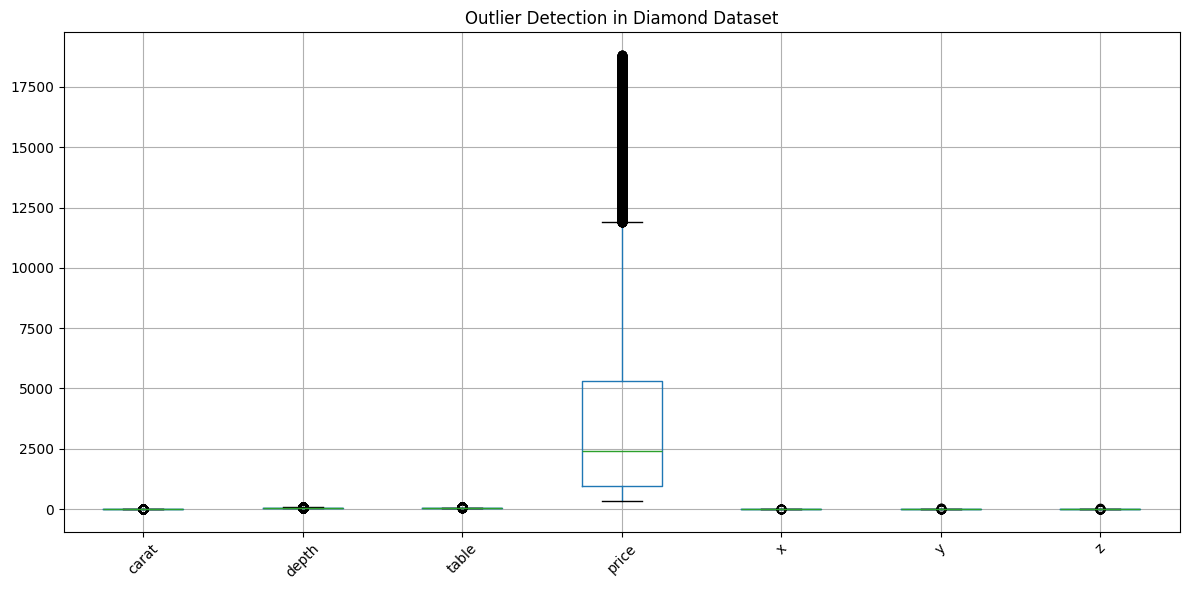

In [14]:
plt.figure(figsize=(12, 6))

df[numeric_columns].boxplot()

plt.title("Outlier Detection in Diamond Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower=lower_limit, upper=upper_limit)

print("Outliers treated successfully!")

Outliers treated successfully!


In [16]:
print("Diamond Price Statistics:")

print("Mean Price:", df["price"].mean())
print("Median Price:", df["price"].median())
print("Minimum Price:", df["price"].min())
print("Maximum Price:", df["price"].max())
print("Standard Deviation:", df["price"].std())

Diamond Price Statistics:
Mean Price: 3732.145689655172
Median Price: 2401.0
Minimum Price: 326.0
Maximum Price: 11885.625
Standard Deviation: 3436.7693441172614


In [17]:
correlation_matrix = df[numeric_columns].corr()

print("Correlation Matrix:")
print(correlation_matrix["price"].sort_values(ascending=False))

Correlation Matrix:
price    1.000000
carat    0.936588
y        0.913492
x        0.911965
z        0.905016
table    0.136891
depth   -0.008726
Name: price, dtype: float64


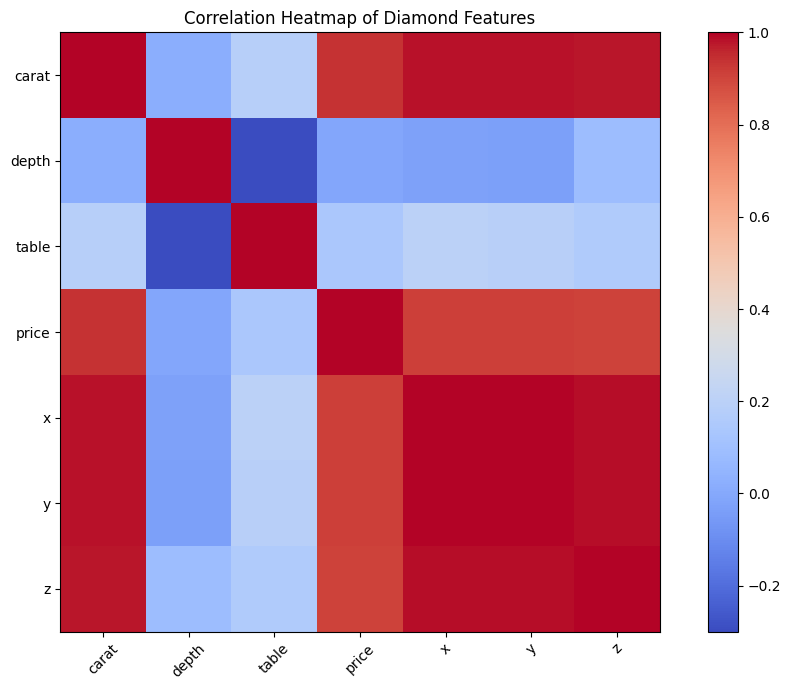

In [18]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap of Diamond Features")
plt.tight_layout()
plt.show()

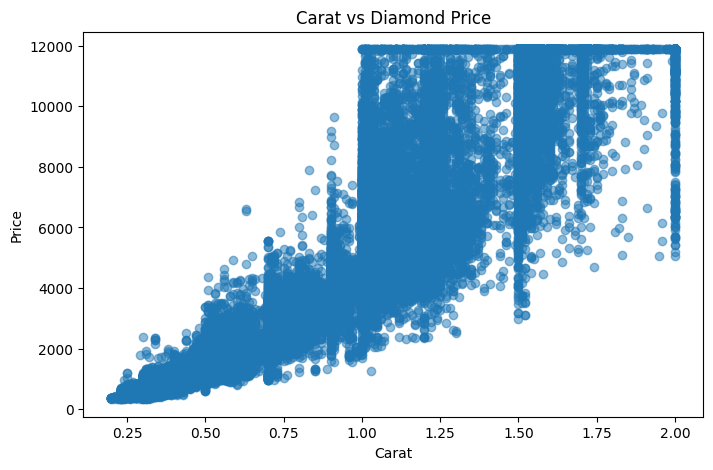

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(df["carat"], df["price"], alpha=0.5)

plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Carat vs Diamond Price")

plt.show()

In [20]:
average_price_by_cut = df.groupby("cut")["price"].mean().sort_values(ascending=False)

print("Average Price by Cut:")
print(average_price_by_cut)

Average Price by Cut:
cut
Premium      4302.705333
Fair         4181.654115
Very Good    3787.707592
Good         3757.335839
Ideal        3296.565977
Name: price, dtype: float64


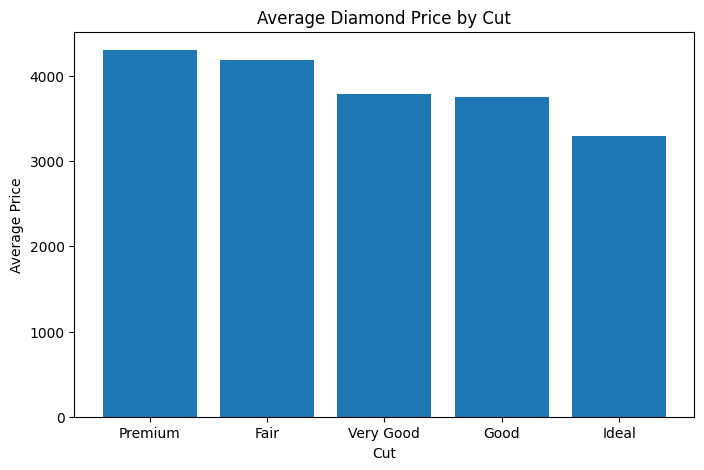

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(average_price_by_cut.index, average_price_by_cut.values)

plt.xlabel("Cut")
plt.ylabel("Average Price")
plt.title("Average Diamond Price by Cut")

plt.show()

In [22]:
average_price_by_color = df.groupby("color")["price"].mean().sort_values(ascending=False)

print("Average Price by Color:")
print(average_price_by_color)

Average Price by Color:
color
J    5003.745860
I    4693.184918
H    4233.643470
G    3802.317326
F    3559.052086
D    3057.349649
E    2965.092375
Name: price, dtype: float64


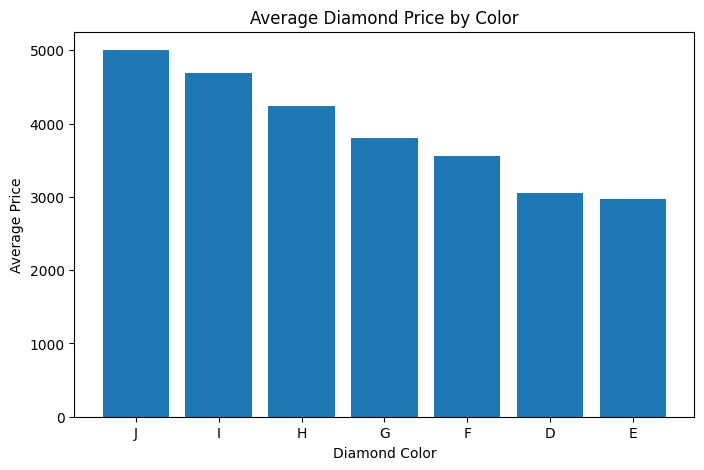

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(average_price_by_color.index, average_price_by_color.values)

plt.xlabel("Diamond Color")
plt.ylabel("Average Price")
plt.title("Average Diamond Price by Color")

plt.show()

In [24]:
average_price_by_clarity = df.groupby("clarity")["price"].mean().sort_values(ascending=False)

print("Average Price by Clarity:")
print(average_price_by_clarity)

Average Price by Clarity:
clarity
SI2     4712.153198
I1      3861.557018
SI1     3812.657539
VS2     3718.993973
VS1     3659.131976
VVS2    3181.197839
IF      2685.086243
VVS1    2436.708447
Name: price, dtype: float64


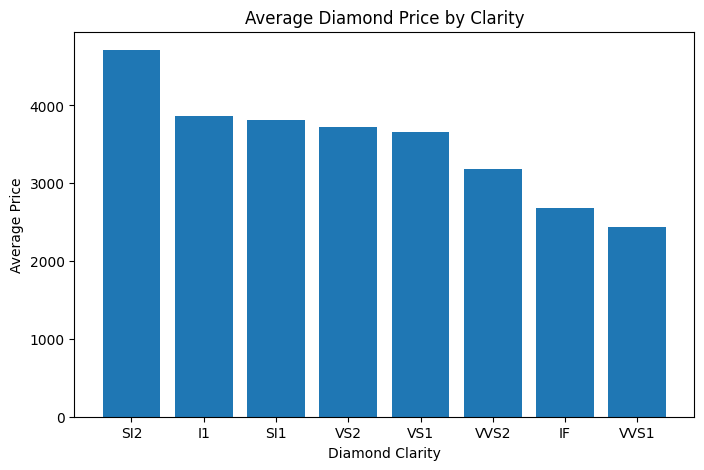

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(average_price_by_clarity.index, average_price_by_clarity.values)

plt.xlabel("Diamond Clarity")
plt.ylabel("Average Price")
plt.title("Average Diamond Price by Clarity")

plt.show()

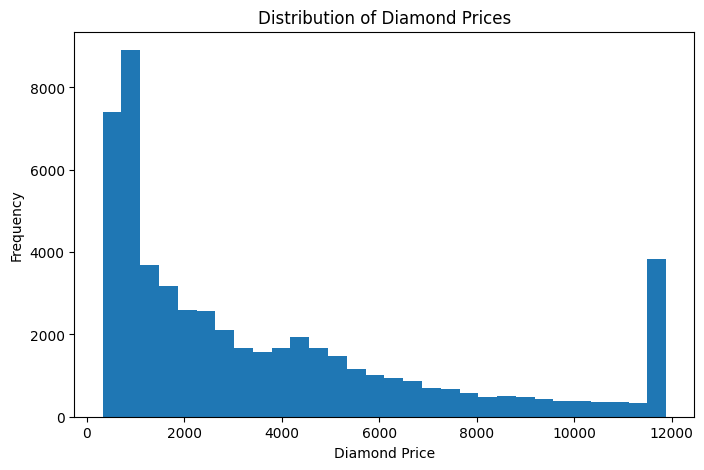

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(df["price"], bins=30)

plt.xlabel("Diamond Price")
plt.ylabel("Frequency")
plt.title("Distribution of Diamond Prices")

plt.show()

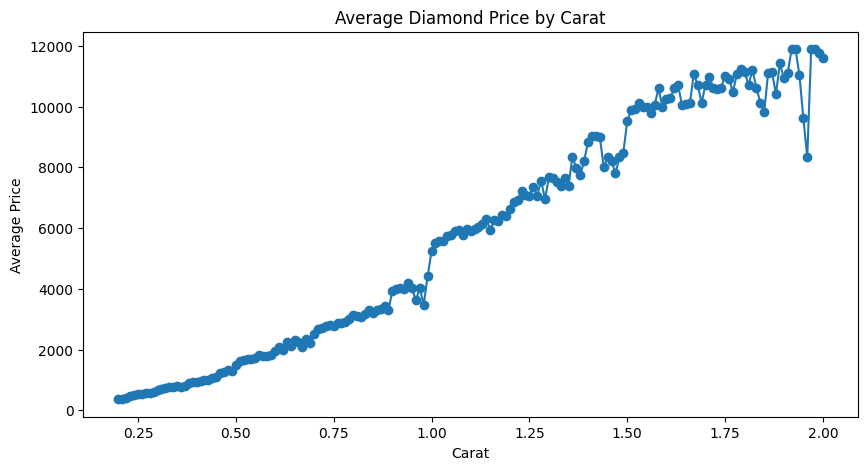

In [27]:
average_price_by_carat = df.groupby("carat")["price"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    average_price_by_carat.index,
    average_price_by_carat.values,
    marker="o"
)

plt.xlabel("Carat")
plt.ylabel("Average Price")
plt.title("Average Diamond Price by Carat")

plt.show()

In [28]:
price_correlations = df[numeric_columns].corr()["price"].drop("price")

print("Features most strongly related to diamond price:")
print(price_correlations.abs().sort_values(ascending=False))

Features most strongly related to diamond price:
carat    0.936588
y        0.913492
x        0.911965
z        0.905016
table    0.136891
depth    0.008726
Name: price, dtype: float64


## Business Insights and Conclusions

### Key Insights

1. The dataset contains information about diamond characteristics such as carat, cut, color, clarity, depth, table, and dimensions.

2. Missing values and duplicate records were checked and handled during the data cleaning process.

3. Descriptive statistics were used to understand the distribution and variation of numerical features.

4. Outliers were detected using box plots and treated using the IQR method.

5. Correlation analysis showed that some numerical features have a strong relationship with diamond price.

6. Carat is an important factor associated with diamond price. Generally, larger diamonds tend to have higher prices.

7. The average price of diamonds was compared across different cut categories.

8. The average price was also analyzed across different color categories.

9. Clarity levels were compared to understand their relationship with average diamond price.

10. Visualizations such as bar charts, scatter plots, histograms, line charts, and heatmaps helped identify patterns in the dataset.

### Business Recommendations

- Diamond sellers should consider carat as an important pricing factor.
- Pricing strategies should also consider cut, color, and clarity.
- High-value diamonds can be identified using their combination of carat, cut, color, and clarity.
- Businesses can use these insights to improve pricing decisions and understand customer preferences.
- Data analysis can help identify important diamond characteristics that contribute to higher prices.

### Conclusion

The Diamond Price Analysis project successfully explored how different diamond features are related to price. Data cleaning, statistical analysis, outlier treatment, correlation analysis, and visualization were performed using Python, Pandas, NumPy, and Matplotlib. The analysis provides useful business insights that can support diamond pricing and decision-making.